In [22]:
# Install the libraries required for this experiment

!pip install -q pandas numpy matplotlib scikit-learn wfdb pillow

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import wfdb
from PIL import Image
from io import BytesIO
import requests
from collections import Counter

In [24]:
# URL of the Cleveland Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names according to the Cleveland dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Read the dataset
df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [25]:
print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Dataset Shape:
(303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [26]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [27]:
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing numerical values with their median
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [28]:
# Convert target:
# 0 = No heart disease
# 1,2,3,4 = Heart disease

df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [29]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (303, 13)
Target shape: (303,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [32]:
scaler.fit_transform(X_train)

array([[-0.72948484,  0.68313005,  0.8701687 , ...,  0.67505958,
        -0.68971531,  1.17997269],
       [ 0.05016647,  0.68313005, -1.18427838, ..., -0.9585846 ,
        -0.68971531, -0.87806977],
       [-0.06121229, -1.46385011, -1.18427838, ..., -0.9585846 ,
         0.44573438, -0.87806977],
       ...,
       [ 1.38671155,  0.68313005,  0.8701687 , ...,  0.67505958,
         1.58118408,  1.17997269],
       [ 1.60946907,  0.68313005, -0.15705484, ...,  0.67505958,
         2.71663377,  1.17997269],
       [-0.72948484,  0.68313005, -1.18427838, ...,  2.30870375,
        -0.68971531,  1.17997269]])

In [33]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [34]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1]


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8688524590163934
Accuracy (%): 86.88524590163934


In [36]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9512987012987013


Confusion Matrix:
[[27  6]
 [ 2 26]]


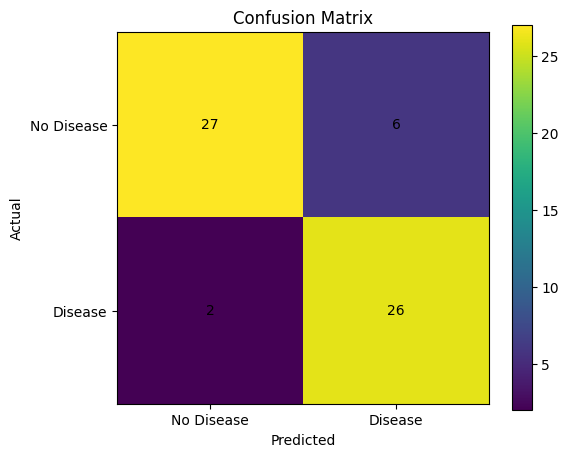

In [37]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.yticks([0, 1], ["No Disease", "Disease"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [38]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [39]:
# Download and read record 100 from MIT-BIH database
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of channels:", record.n_sig)

ECG record loaded successfully!
Signal shape: (650000, 2)
Sampling frequency: 360
Number of channels: 2


In [40]:
print("Sampling Frequency:", record.fs, "Hz")
print("Number of Samples:", record.sig_len)
print("Number of Channels:", record.n_sig)

print("Signal Names:")
print(record.sig_name)

Sampling Frequency: 360 Hz
Number of Samples: 650000
Number of Channels: 2
Signal Names:
['MLII', 'V5']


In [41]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Number of annotations:", len(annotation.sample))

print("First 20 annotation symbols:")
print(annotation.symbol[:20])

Number of annotations: 2274
First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


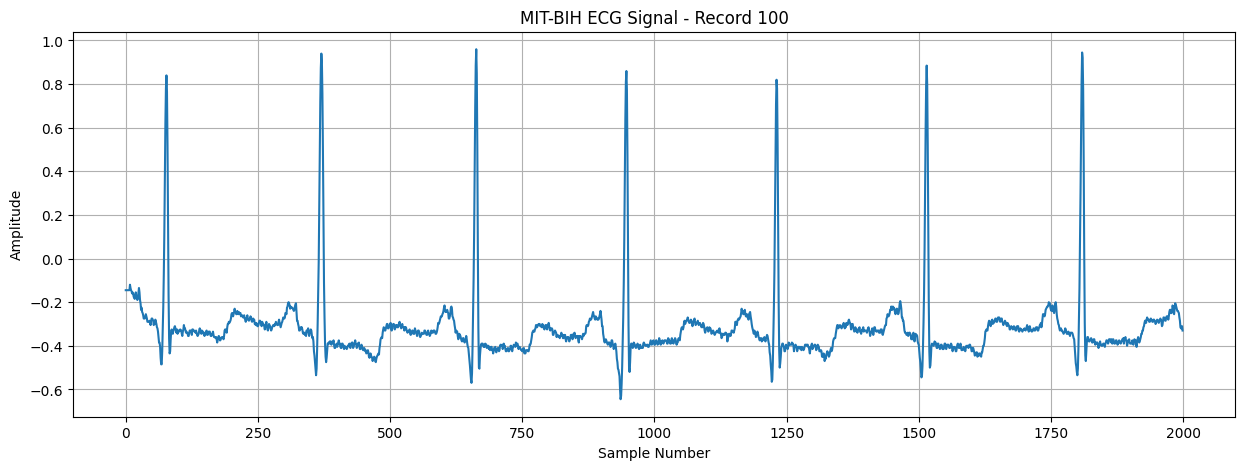

In [42]:
# Take the first 2000 samples
samples = 2000

ecg_signal = record.p_signal[:samples, 0]

plt.figure(figsize=(15, 5))

plt.plot(ecg_signal)

plt.title("MIT-BIH ECG Signal - Record 100")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

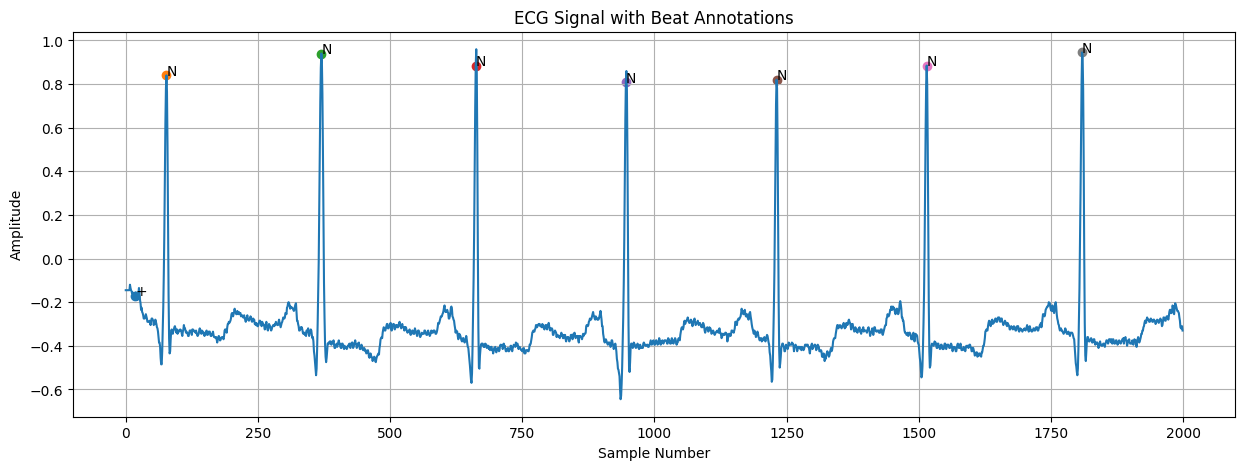

In [43]:
plt.figure(figsize=(15, 5))

plt.plot(
    record.p_signal[:2000, 0],
    label="ECG Signal"
)

# Add annotation points that fall within first 2000 samples
for sample, symbol in zip(annotation.sample, annotation.symbol):
    if sample < 2000:
        plt.scatter(
            sample,
            record.p_signal[sample, 0],
            marker="o"
        )
        plt.text(
            sample,
            record.p_signal[sample, 0],
            symbol
        )

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

In [44]:
# Keep only beat annotations commonly represented by "N"
normal_beats = annotation.sample[
    np.array(annotation.symbol) == "N"
]

# Calculate differences between consecutive normal beats
rr_intervals = np.diff(normal_beats)

print("Number of normal beats:", len(normal_beats))

if len(rr_intervals) > 0:
    print("Average RR interval:", np.mean(rr_intervals), "samples")
    print("Minimum RR interval:", np.min(rr_intervals), "samples")
    print("Maximum RR interval:", np.max(rr_intervals), "samples")

Number of normal beats: 2239
Average RR interval: 290.3994638069705 samples
Minimum RR interval: 235 samples
Maximum RR interval: 600 samples


In [45]:
clinical_note = """
Patient reports chest pain and shortness of breath.
The patient experienced mild chest discomfort during exercise.
Heart rate was elevated and blood pressure was monitored.
"""

print("Clinical Note:")
print(clinical_note)

Clinical Note:

Patient reports chest pain and shortness of breath.
The patient experienced mild chest discomfort during exercise.
Heart rate was elevated and blood pressure was monitored.



In [46]:
# Convert text to lowercase
text = clinical_note.lower()

# Remove basic punctuation
for char in [".", ",", "!", "?", ";", ":"]:
    text = text.replace(char, "")

# Split text into words
tokens = text.split()

print("Tokens:")
print(tokens)

Tokens:
['patient', 'reports', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'experienced', 'mild', 'chest', 'discomfort', 'during', 'exercise', 'heart', 'rate', 'was', 'elevated', 'and', 'blood', 'pressure', 'was', 'monitored']


In [47]:
word_frequency = Counter(tokens)

print("Word Frequency:")
for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:
patient : 2
chest : 2
and : 2
was : 2
reports : 1
pain : 1
shortness : 1
of : 1
breath : 1
the : 1
experienced : 1
mild : 1
discomfort : 1
during : 1
exercise : 1
heart : 1
rate : 1
elevated : 1
blood : 1
pressure : 1
monitored : 1


In [48]:
medical_terms = [
    "chest",
    "pain",
    "shortness",
    "breath",
    "heart",
    "blood",
    "pressure",
    "exercise"
]

found_terms = {
    term: word_frequency[term]
    for term in medical_terms
    if word_frequency[term] > 0
}

print("Medical terms found:")
print(found_terms)

Medical terms found:
{'chest': 2, 'pain': 1, 'shortness': 1, 'breath': 1, 'heart': 1, 'blood': 1, 'pressure': 1, 'exercise': 1}


Image created successfully.


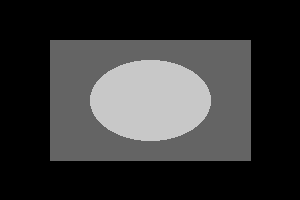

In [49]:
from PIL import Image, ImageDraw

# Create a grayscale image
image = Image.new("L", (300, 200), 0)

draw = ImageDraw.Draw(image)

# Draw a simple synthetic pattern
draw.rectangle((50, 40, 250, 160), fill=100)
draw.ellipse((90, 60, 210, 140), fill=200)

print("Image created successfully.")

display(image)

In [50]:
print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image format: None
Image size: (300, 200)
Image mode: L


Original size: (300, 200)
New size: (150, 100)


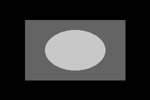

In [51]:
resized_image = image.resize((150, 100))

print("Original size:", image.size)
print("New size:", resized_image.size)

display(resized_image)

In [52]:
image_array = np.array(resized_image)

normalized_image = image_array / 255.0

print("Original pixel range:")
print(image_array.min(), "to", image_array.max())

print("\nNormalized pixel range:")
print(normalized_image.min(), "to", normalized_image.max())

Original pixel range:
0 to 207

Normalized pixel range:
0.0 to 0.8117647058823529


In [53]:
multimodal_data = {
    "Tabular Data": {
        "source": "Cleveland Heart Disease Dataset",
        "features": X.shape[1],
        "records": X.shape[0]
    },

    "ECG Signal": {
        "source": "MIT-BIH Arrhythmia Database",
        "sampling_frequency": record.fs,
        "channels": record.n_sig
    },

    "Text Data": {
        "source": "Synthetic Clinical Note",
        "number_of_tokens": len(tokens),
        "unique_words": len(word_frequency)
    },

    "Image Data": {
        "source": "Synthetic Image",
        "original_size": image.size,
        "resized_size": resized_image.size
    }
}

for modality, information in multimodal_data.items():
    print("\n", modality)
    for key, value in information.items():
        print(f"{key}: {value}")


 Tabular Data
source: Cleveland Heart Disease Dataset
features: 13
records: 303

 ECG Signal
source: MIT-BIH Arrhythmia Database
sampling_frequency: 360
channels: 2

 Text Data
source: Synthetic Clinical Note
number_of_tokens: 25
unique_words: 21

 Image Data
source: Synthetic Image
original_size: (300, 200)
resized_size: (150, 100)


In [54]:
print("=" * 60)
print("LAB EXPERIMENT 1 - FINAL SUMMARY")
print("=" * 60)

print("\n1. TABULAR / MEDICAL DATA")
print("   Dataset: Cleveland Heart Disease Dataset")
print("   Records:", len(df))
print("   Features:", X.shape[1])
print("   Model: Logistic Regression")
print("   Accuracy:", round(accuracy * 100, 2), "%")
print("   ROC-AUC:", round(roc_auc, 4))

print("\n2. SIGNAL DATA")
print("   Dataset: MIT-BIH Arrhythmia Database")
print("   ECG Record: 100")
print("   Sampling Frequency:", record.fs, "Hz")
print("   Channels:", record.n_sig)

print("\n3. TEXT DATA")
print("   Number of Tokens:", len(tokens))
print("   Unique Words:", len(word_frequency))

print("\n4. IMAGE DATA")
print("   Original Size:", image.size)
print("   Resized Size:", resized_image.size)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 60)

LAB EXPERIMENT 1 - FINAL SUMMARY

1. TABULAR / MEDICAL DATA
   Dataset: Cleveland Heart Disease Dataset
   Records: 303
   Features: 13
   Model: Logistic Regression
   Accuracy: 86.89 %
   ROC-AUC: 0.9513

2. SIGNAL DATA
   Dataset: MIT-BIH Arrhythmia Database
   ECG Record: 100
   Sampling Frequency: 360 Hz
   Channels: 2

3. TEXT DATA
   Number of Tokens: 25
   Unique Words: 21

4. IMAGE DATA
   Original Size: (300, 200)
   Resized Size: (150, 100)

EXPERIMENT COMPLETED SUCCESSFULLY
